# Customer Segmentation Using KMeans Clustering

## Project Overview

This project performs customer segmentation using **unsupervised learning**. 
Unlike supervised learning, there is no target variable to predict. Instead, 
the goal is to discover groups of customers with similar characteristics.

The dataset contains customer information such as:

- Age
- Annual Income
- Spending Score

KMeans clustering is used to identify meaningful customer segments based on 
these features.

### Objectives

- Explore and understand the customer dataset
- Perform exploratory data analysis (EDA)
- Scale the clustering features
- Apply KMeans clustering with different numbers of clusters
- Use the Elbow Method to select an appropriate number of clusters
- Profile and interpret the resulting customer segments
- Use PCA to visualize the clusters in two dimensions
- Save the final clustering model and scaler for future use

## Project Workflow

The project follows this workflow:

**Data Loading → Data Exploration → EDA → Feature Selection → Scaling → 
KMeans Experimentation → Elbow Method → Final Clustering → Cluster Profiling 
→ PCA Visualization → Model Saving**

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

## 1. Load the Dataset

The dataset contains demographic and spending information for mall customers.

Before performing clustering, the data will be inspected for its structure,
data types, missing values, and duplicate records.

In [4]:
DATA_PATH = "../data/Mall_Customers.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
print(f"Dataset contains {df.shape[0]} customers and {df.shape[1]} columns.")

Dataset contains 200 customers and 5 columns.


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


### Initial Data Observations

The dataset is checked for missing values and duplicate records before 
proceeding with analysis. No Duplizates and missing values found. The customer identifier is retained for reference 
but will not be used as a clustering feature because it does not describe 
customer behavior.

In [9]:
df.columns.tolist()

['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

## 2. Feature Selection

For customer segmentation, the following numerical features are selected:

- **Age** – customer demographic information
- **Annual Income (k$)** – approximate annual income
- **Spending Score (1-100)** – spending behavior assigned by the mall

`CustomerID` is excluded because it is only an identifier and has no 
meaningful relationship with customer similarity.

Gender will be explored during EDA but is not included in the KMeans model 
to keep the segmentation focused on the numerical behavioral and demographic 
variables specified for this project.

In [10]:
features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features]
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


## 3. Exploratory Data Analysis

EDA is performed to understand the distributions of the variables and identify
patterns that may help explain the customer segments discovered later.

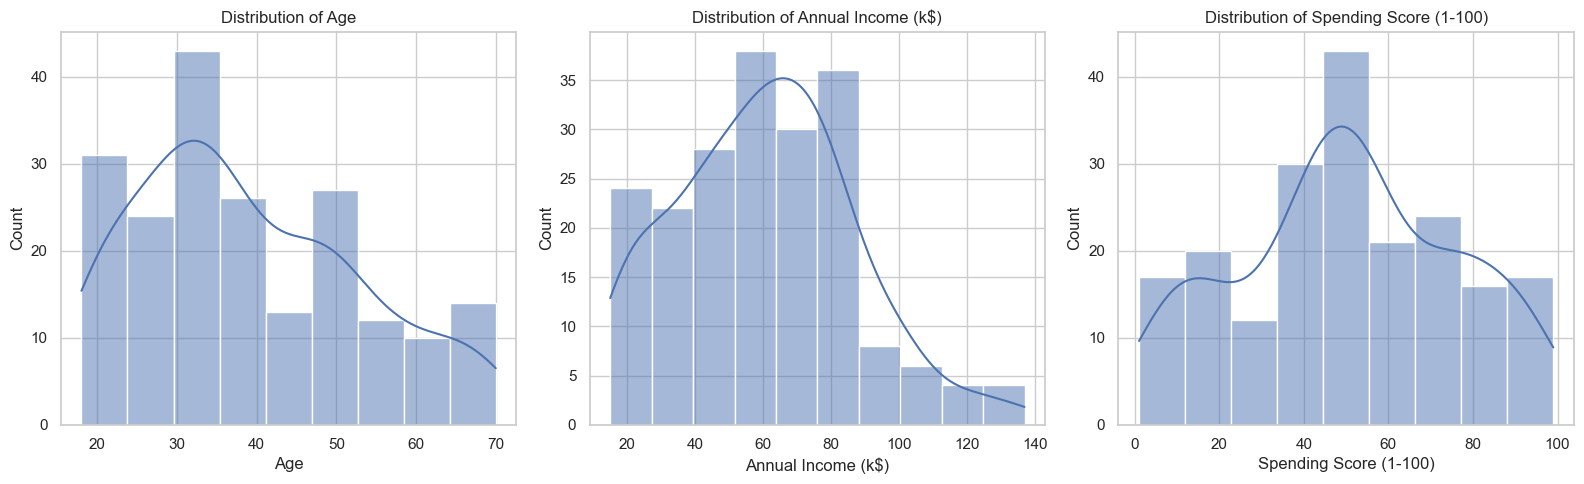

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feature in zip(axes, features):
    sns.histplot(data=df, x=feature, kde=True, ax=ax)
    ax.set_title(f"Distribution of {feature}")
plt.savefig(
    "../visualizations/feature_distributions.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

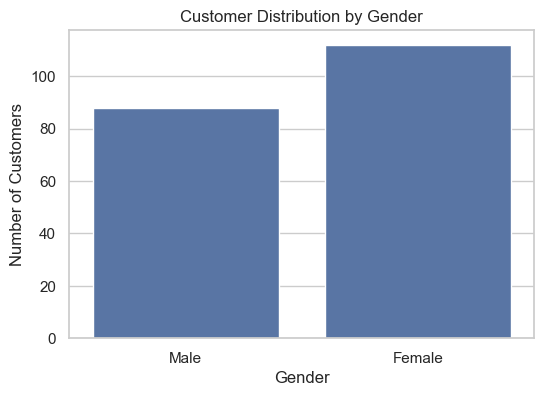

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Gender")
plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.savefig(
    "../visualizations/customer_distribution_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

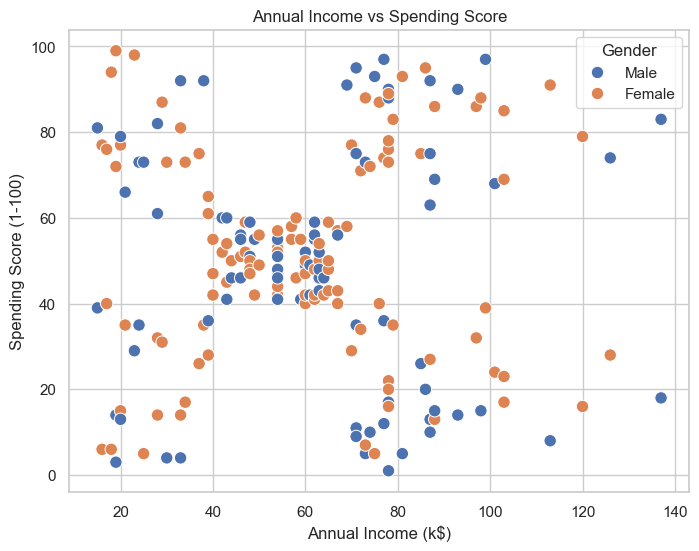

In [16]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Gender",
    s=80
)

plt.title("Annual Income vs Spending Score")
plt.show()

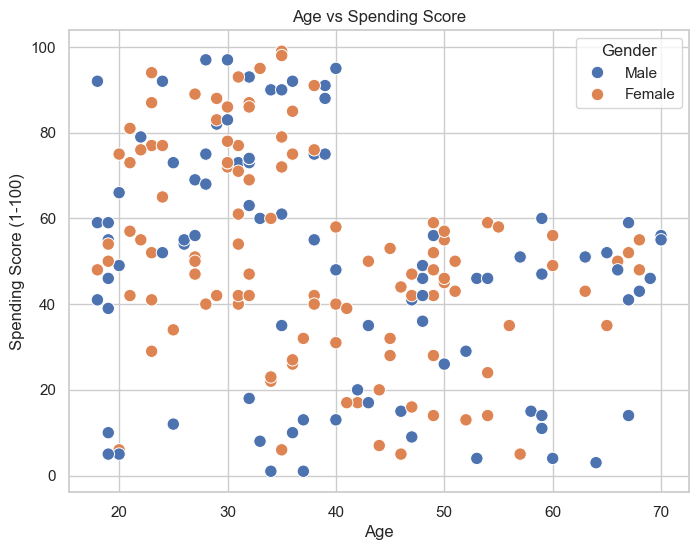

<Figure size 640x480 with 0 Axes>

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)",
    hue="Gender",
    s=80
)

plt.title("Age vs Spending Score")
plt.show()
plt.savefig(
    "../visualizations//income_vs_spending_eda.png",
    dpi=300,
    bbox_inches="tight"
)

### EDA Observations

The distributions show variation in customer age, income, and spending 
behavior. The scatter plots also indicate that customers do not form a 
single homogeneous group. Differences in income and spending behavior 
suggest that clustering may reveal distinct customer segments.

The observed patterns provide motivation for applying an unsupervised 
clustering algorithm.

## 4. Feature Scaling

KMeans clustering is distance-based, so features with larger numerical 
scales can have a greater influence on the clustering process.

StandardScaler is therefore used to transform the selected features so that 
they are on a comparable scale.

The scaler will also be saved later because the same transformation must be 
applied to any new customer data before making cluster assignments.

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(
    X_scaled,
    columns=features,
    index=df.index
)

X_scaled.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


## 5. KMeans Clustering

KMeans divides observations into a predefined number of clusters.

The algorithm works by:

1. Selecting initial cluster centroids
2. Assigning each customer to the nearest centroid
3. Updating the centroids based on the assigned customers
4. Repeating the process until the cluster assignments stabilize

Since the appropriate number of clusters is not known beforehand, several 
values of K will be evaluated.

In [22]:
k_range = range(2, 11)
inertias = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_scaled)
    inertias.append(model.inertia_)

print("Inertia values:")
for k, inertia in zip(k_range, inertias):
    print(f"K = {k}: Inertia = {inertia:.2f}")

Inertia values:
K = 2: Inertia = 389.39
K = 3: Inertia = 295.21
K = 4: Inertia = 205.23
K = 5: Inertia = 168.25
K = 6: Inertia = 133.87
K = 7: Inertia = 117.01
K = 8: Inertia = 103.87
K = 9: Inertia = 93.09
K = 10: Inertia = 82.39


## 6. Elbow Method

The Elbow Method evaluates how within-cluster variation changes as the 
number of clusters increases.

**Inertia** measures the total squared distance between each observation 
and its assigned cluster centroid.

As K increases, inertia generally decreases. The goal is to identify a 
point where adding additional clusters produces a noticeably smaller 
improvement. This point is referred to as the "elbow."

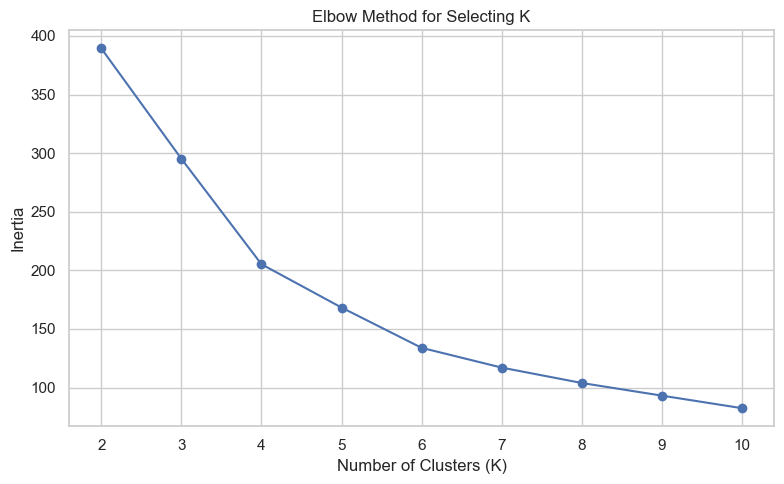

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Selecting K")
plt.xticks(list(k_range))
plt.tight_layout()
plt.savefig(
    "../visualizations//elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

The inertia decreases substantially from K=2 to K=4. After K=5, the 
reduction in inertia becomes progressively smaller, indicating diminishing 
returns from adding additional clusters.

Based on this trade-off between cluster compactness and model simplicity.

**K=5 was selected as the final number of clusters**.

## 7. Final KMeans Model

Based on the Elbow Method, **K=5** was selected as the final number of 
clusters.

The final KMeans model is now trained using the five selected clusters.

In [27]:
BEST_K = 5
final_kmeans = KMeans(
    n_clusters=BEST_K,
    random_state=42,
    n_init=10
)
df["Cluster"] = final_kmeans.fit_predict(X_scaled)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


### Cluster Distribution

Before interpreting the clusters, the number of customers assigned to each 
cluster is examined. This helps identify whether the resulting segments are 
reasonably distributed or whether some groups are substantially smaller than 
others.

In [28]:
cluster_counts = (
    df["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Customer Count")
)
cluster_counts

Cluster
0    20
1    54
2    40
3    39
4    47
Name: Customer Count, dtype: int64

## 8. Cluster Profiling

The clusters are profiled using the average values of Age, Annual Income, 
and Spending Score.

These averages allow us to understand the characteristics of each customer 
segment and describe them in plain English.

In [29]:
cluster_profile = (
    df.groupby("Cluster")[features]
    .mean()
    .round(2)
)
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.25,26.75,18.35
1,25.19,41.09,62.24
2,32.88,86.10,81.53
3,39.87,86.10,19.36
4,55.64,54.38,48.85


In [30]:
cluster_profile["Customer Count"] = cluster_counts
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Customer Count
Cluster,,,,
0,46.25,26.75,18.35,20
1,25.19,41.09,62.24,54
2,32.88,86.10,81.53,40
3,39.87,86.10,19.36,39
4,55.64,54.38,48.85,47


In [31]:
cluster_profile.to_csv(
    "../results/cluster_profiles.csv"
)
print("Cluster profile saved successfully.")

Cluster profile saved successfully.


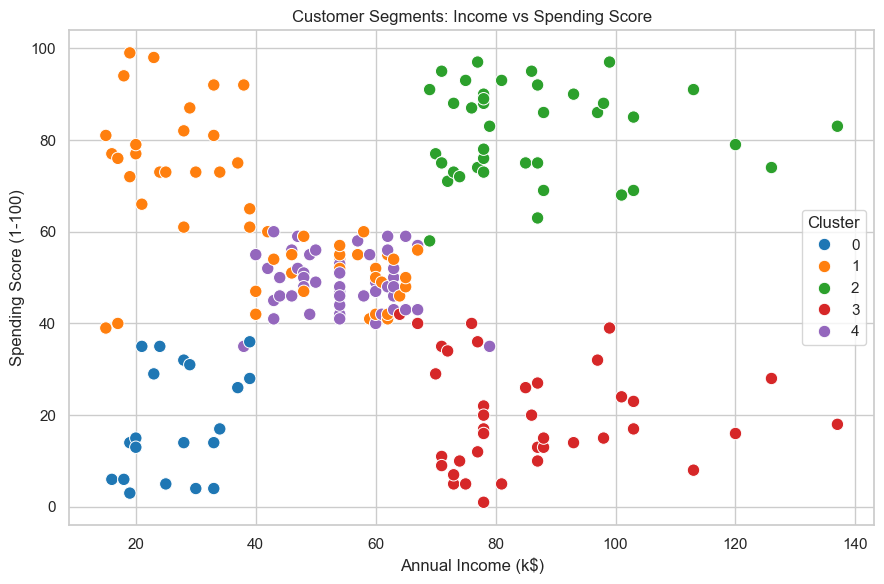

In [32]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="tab10",
    s=80
)
plt.title("Customer Segments: Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")

plt.tight_layout()

plt.savefig(
    "../visualizations/income_vs_spending_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. PCA Visualization

The clustering was performed using all three scaled features. To visualize 
the resulting clusters in two dimensions, Principal Component Analysis (PCA) 
is applied.

PCA reduces the three-dimensional feature space to two principal components 
while preserving as much variation in the data as possible.

PCA is used **only for visualization**. It is not used to train the KMeans 
model.

In [35]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=df.index
)
pca_df["Cluster"] = df["Cluster"]
print(
    f"Variance explained by PC1: "
    f"{pca.explained_variance_ratio_[0]:.2%}"
)
print(
    f"Variance explained by PC2: "
    f"{pca.explained_variance_ratio_[1]:.2%}"
)
print(
    f"Total variance explained by two components: "
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

Variance explained by PC1: 44.27%
Variance explained by PC2: 33.31%
Total variance explained by two components: 77.57%


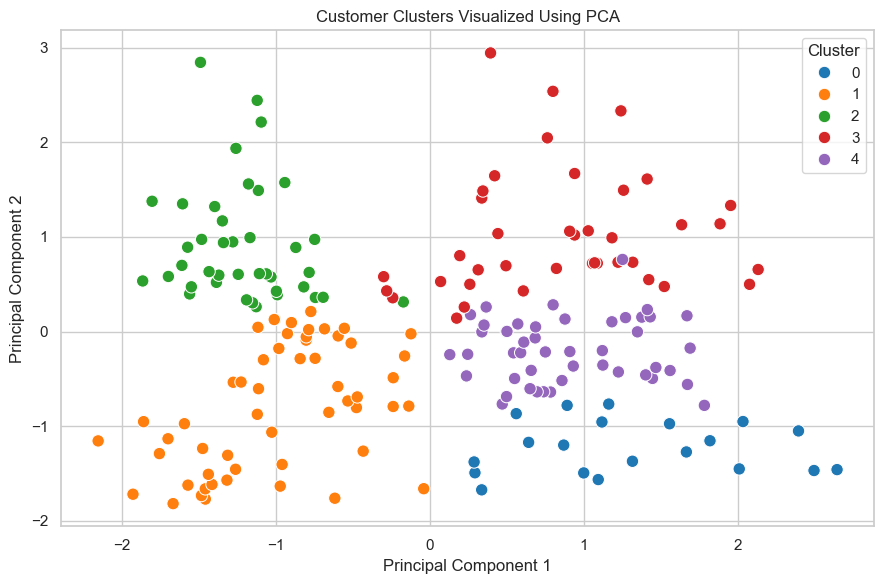

In [36]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=80
)

plt.title("Customer Clusters Visualized Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig(
    "../visualizations//pca_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Customer Segment Interpretation

The five clusters show distinct customer profiles based on age, annual income,
and spending score.

### Cluster 0 — Low-Income, Low-Spending Customers

These customers have an average age of 46.25 years, annual income of about
$26.75k, and a low average spending score of 18.35. They represent a
relatively low-income and low-spending segment.

### Cluster 1 — Young, High-Spending Customers

These customers are relatively young, with an average age of 25.19 years.
Their average income is about $41.09k, while their spending score is 62.24.
Despite having moderate income, they show relatively high spending behavior.

### Cluster 2 — High-Value Customers

This group has an average age of 32.88 years, high annual income of about
$86.10k, and the highest spending score of 81.53. These customers represent
the most valuable segment in terms of both income and spending behavior.

### Cluster 3 — High-Income, Low-Spending Customers

These customers have a relatively high average income of $86.10k but a low
spending score of 19.36. This difference between high purchasing capacity
and low spending behavior makes this group particularly interesting for
targeted marketing strategies.

### Cluster 4 — Mature, Moderate-Spending Customers

This segment has the highest average age at 55.64 years, with an average
income of $54.38k and spending score of 48.85. These customers show a more
balanced combination of income and spending behavior.

### Overall Observation

The clustering reveals that income alone does not determine spending
behavior. For example, Clusters 2 and 3 have the same average income of
approximately $86.10k but very different spending scores. This demonstrates
why considering multiple customer characteristics together is useful for
customer segmentation.

## 11. Saving the Final Model

The final KMeans model and the fitted StandardScaler are saved using Joblib.

Both files are required to assign new customers to the learned segments. 
New customer data must first be transformed using the same scaler and then 
passed to the trained KMeans model.

In [38]:
joblib.dump(
    final_kmeans,
    "../models/kmeans_model.pkl"
)
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)
print("Final KMeans model saved to: models/kmeans_model.pkl")
print("Scaler saved to: models/scaler.pkl")

Final KMeans model saved to: models/kmeans_model.pkl
Scaler saved to: models/scaler.pkl


In [40]:
loaded_model = joblib.load("../models/kmeans_model.pkl")
loaded_scaler = joblib.load("../models/scaler.pkl")
print("Model loaded successfully:", type(loaded_model).__name__)
print("Scaler loaded successfully:", type(loaded_scaler).__name__)

Model loaded successfully: KMeans
Scaler loaded successfully: StandardScaler


## 12. Testing the Saved Model

To verify that the saved KMeans model can be reused, a sample customer is
passed through the saved scaler and KMeans model.

Because clustering is unsupervised, there is no target label to compare
against. Instead, the predicted cluster is interpreted using the cluster
profiles generated earlier.

In [43]:
test_customers = pd.DataFrame({
    "Age": [25, 40, 55],
    "Annual Income (k$)": [85, 85, 30],
    "Spending Score (1-100)": [80, 20, 15]
})
test_scaled = loaded_scaler.transform(test_customers)
predicted_clusters = loaded_model.predict(test_scaled)
test_customers["Predicted Cluster"] = predicted_clusters
test_customers

,Age,Annual Income (k$),Spending Score (1-100),Predicted Cluster
0,25,85,80,2
1,40,85,20,3
2,55,30,15,0


## 12. Conclusion

This project applied unsupervised learning to segment mall customers based 
on age, annual income, and spending score.

The selected features were standardized before applying KMeans because the 
algorithm relies on distance measurements. Different cluster counts were 
evaluated, and the Elbow Method indicated that **K=5** provided a reasonable 
balance between reducing inertia and maintaining a manageable number of 
customer segments.

The final clusters were profiled using their average demographic and 
spending characteristics, allowing each segment to be interpreted in 
business terms. PCA was then used to visualize the resulting clusters in 
two dimensions.

The final KMeans model and StandardScaler were saved so that the learned 
segmentation can be reused on new customer data.